Using device: cuda
36000 4000 10000

Dropout: 0.3 Batch: 128
Epoch 1: Train Acc 0.502 | Val Acc 0.504
Epoch 2: Train Acc 0.502 | Val Acc 0.496
Epoch 3: Train Acc 0.508 | Val Acc 0.504
Epoch 4: Train Acc 0.500 | Val Acc 0.496
Epoch 5: Train Acc 0.501 | Val Acc 0.504


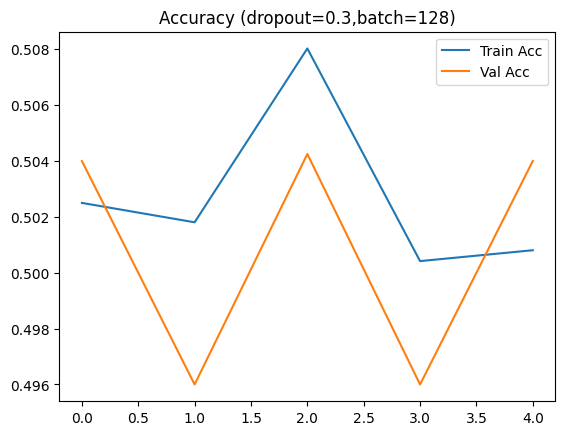

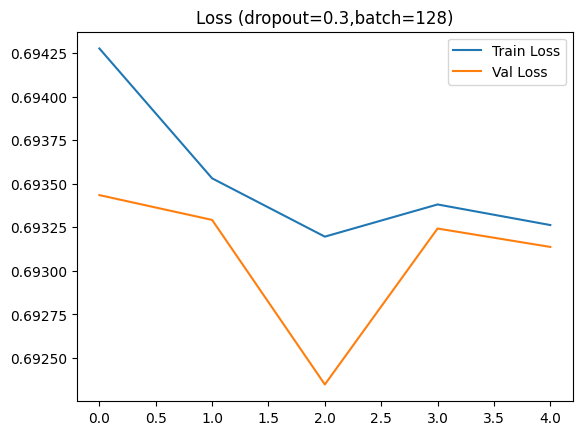

Precision: 0.51
Recall: 1.00
F1 Score: 0.67

Dropout: 0.3 Batch: 512
Epoch 1: Train Acc 0.503 | Val Acc 0.511
Epoch 2: Train Acc 0.521 | Val Acc 0.496
Epoch 3: Train Acc 0.499 | Val Acc 0.496
Epoch 4: Train Acc 0.502 | Val Acc 0.504
Epoch 5: Train Acc 0.499 | Val Acc 0.496


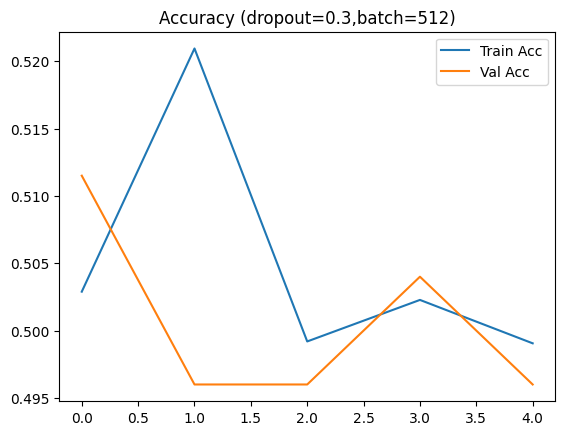

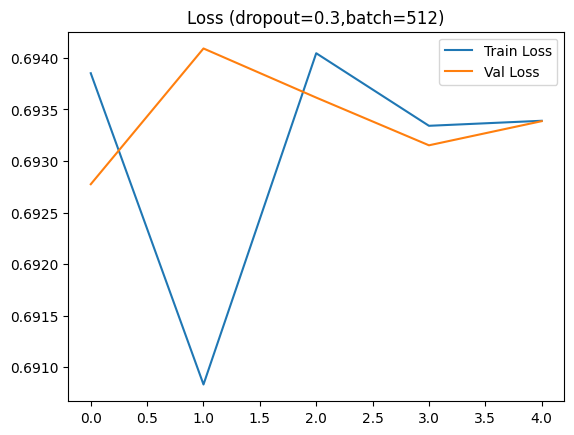

C:\Users\23adsb72\.conda\envs\gpu_72\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.00
Recall: 0.00
F1 Score: 0.00

Dropout: 0.5 Batch: 128
Epoch 1: Train Acc 0.502 | Val Acc 0.504
Epoch 2: Train Acc 0.504 | Val Acc 0.510
Epoch 3: Train Acc 0.510 | Val Acc 0.509
Epoch 4: Train Acc 0.517 | Val Acc 0.539
Epoch 5: Train Acc 0.524 | Val Acc 0.530


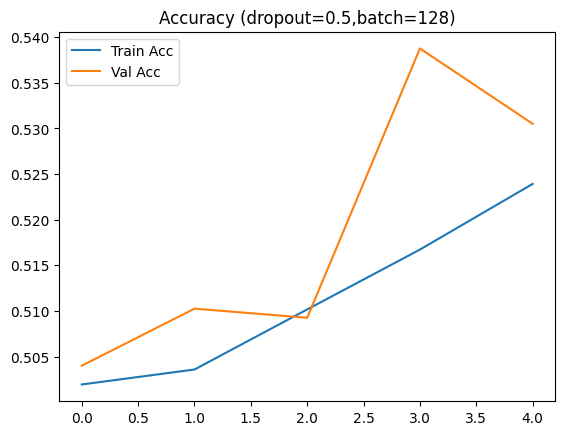

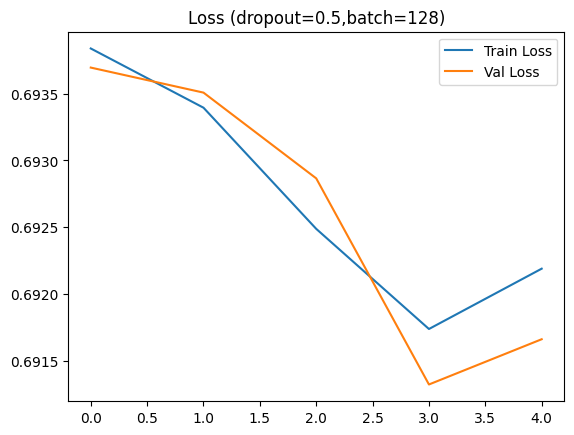

Precision: 0.53
Recall: 0.60
F1 Score: 0.56

Dropout: 0.5 Batch: 512
Epoch 1: Train Acc 0.498 | Val Acc 0.505
Epoch 2: Train Acc 0.515 | Val Acc 0.526
Epoch 3: Train Acc 0.520 | Val Acc 0.503
Epoch 4: Train Acc 0.503 | Val Acc 0.503
Epoch 5: Train Acc 0.503 | Val Acc 0.503


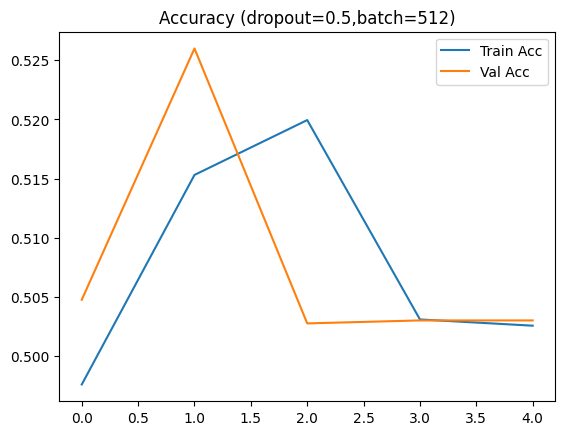

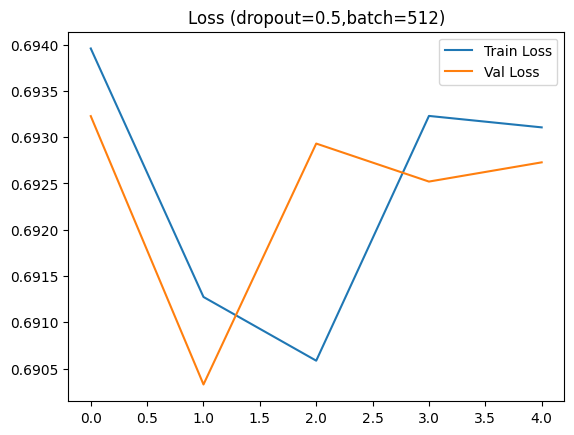

Precision: 0.62
Recall: 0.03
F1 Score: 0.06


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import Counter
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =====================
# Load Dataset
# =====================

df = pd.read_csv("IMDB Dataset.csv")

df["sentiment"] = df["sentiment"].map({"positive":1,"negative":0})

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

print(len(train_df), len(val_df), len(test_df))

# =====================
# Tokenization
# =====================

def tokenize(text):
    return text.lower().split()

counter = Counter()

for text in train_df["review"]:
    counter.update(tokenize(text))

vocab_size = 10000
vocab = {word:i+2 for i,(word,_) in enumerate(counter.most_common(vocab_size))}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

max_len = 200

def encode(text):
    tokens = tokenize(text)
    seq = [vocab.get(t,1) for t in tokens]
    if len(seq) < max_len:
        seq += [0]*(max_len-len(seq))
    else:
        seq = seq[:max_len]
    return seq

# =====================
# Dataset Class
# =====================

class IMDBDataset(Dataset):

    def __init__(self, df):
        self.X = [encode(x) for x in df["review"]]
        self.y = df["sentiment"].values

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx]).float()

train_dataset = IMDBDataset(train_df)
val_dataset = IMDBDataset(val_df)
test_dataset = IMDBDataset(test_df)

# =====================
# Model
# =====================

class StackedRNN(nn.Module):

    def __init__(self, vocab_size, dropout):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,128)

        self.rnn = nn.RNN(
            input_size=128,
            hidden_size=128,
            num_layers=3,
            dropout=dropout,
            batch_first=True
        )

        self.fc1 = nn.Linear(128,64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.embedding(x)

        out,_ = self.rnn(x)

        out = out[:,-1,:]

        out = self.fc1(out)
        out = self.relu(out)

        out = self.fc2(out)

        return self.sigmoid(out)

# =====================
# Experiment settings
# =====================

dropouts = [0.3,0.5]
batch_sizes = [128,512]

epochs = 5
l2 = 1e-4

# =====================
# Run Experiments
# =====================

for dropout in dropouts:
    for batch_size in batch_sizes:

        print("\n==============================")
        print("Dropout:",dropout,"Batch:",batch_size)
        print("==============================")

        train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
        val_loader = DataLoader(val_dataset,batch_size=batch_size)
        test_loader = DataLoader(test_dataset,batch_size=batch_size)

        model = StackedRNN(vocab_size+2,dropout).to(device)

        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=l2)

        train_losses=[]
        val_losses=[]
        train_acc=[]
        val_acc=[]

        for epoch in range(epochs):

            model.train()
            total_loss=0
            correct=0
            total=0

            for X,y in train_loader:

                X=X.to(device)
                y=y.to(device)

                optimizer.zero_grad()

                outputs=model(X).squeeze()

                loss=criterion(outputs,y)

                loss.backward()

                optimizer.step()

                total_loss+=loss.item()

                preds=(outputs>0.5).float()

                correct+=(preds==y).sum().item()

                total+=y.size(0)

            train_losses.append(total_loss/len(train_loader))
            train_acc.append(correct/total)

            model.eval()

            vloss=0
            vcorrect=0
            vtotal=0

            with torch.no_grad():

                for X,y in val_loader:

                    X=X.to(device)
                    y=y.to(device)

                    outputs=model(X).squeeze()

                    loss=criterion(outputs,y)

                    vloss+=loss.item()

                    preds=(outputs>0.5).float()

                    vcorrect+=(preds==y).sum().item()

                    vtotal+=y.size(0)

            val_losses.append(vloss/len(val_loader))
            val_acc.append(vcorrect/vtotal)

            print(f"Epoch {epoch+1}: Train Acc {train_acc[-1]:.3f} | Val Acc {val_acc[-1]:.3f}")

        # =====================
        # Plots
        # =====================

        plt.figure()
        plt.plot(train_acc,label="Train Acc")
        plt.plot(val_acc,label="Val Acc")
        plt.legend()
        plt.title(f"Accuracy (dropout={dropout},batch={batch_size})")
        plt.show()

        plt.figure()
        plt.plot(train_losses,label="Train Loss")
        plt.plot(val_losses,label="Val Loss")
        plt.legend()
        plt.title(f"Loss (dropout={dropout},batch={batch_size})")
        plt.show()

        # =====================
        # Test Metrics
        # =====================

        all_preds=[]
        all_labels=[]

        model.eval()

        with torch.no_grad():

            for X,y in test_loader:

                X=X.to(device)

                outputs=model(X).squeeze()

                preds=(outputs>0.5).cpu().numpy()

                all_preds.extend(preds)
                all_labels.extend(y.numpy())

        precision=precision_score(all_labels,all_preds)
        recall=recall_score(all_labels,all_preds)
        f1=f1_score(all_labels,all_preds)

        print(f"Precision: {precision:.2f}")
        print(f"Recall: {recall:.2f}")
        print(f"F1 Score: {f1:.2f}")